In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import pickle, os
os.makedirs("data", exist_ok=True)

# Load Preprocessed Data

In [2]:
full_df = pd.read_csv("data/cleaned_data.csv")

# Load label encoders so we can decode region/crop names later
with open('data/label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

CLUSTER_FEATURES = [c for c in full_df.columns if c != 'disease_label']
X_scaled = full_df[CLUSTER_FEATURES].values
y = full_df['disease_label'].values   # kept only for post-hoc analysis

print(f"Dataset shape  : {X_scaled.shape[0]} samples  ×  {X_scaled.shape[1]} features")
print(f"Feature list   : {CLUSTER_FEATURES}")

# PCA 2D projection
pca      = PCA(n_components=2, random_state=42)
X_2d     = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_.sum() * 100
print(f"\nPCA 2D variance explained: {explained:.1f}%")
print("(Higher % → 2D plot is more faithful to real distances)")

Dataset shape  : 548 samples  ×  13 features
Feature list   : ['crop_type', 'region', 'disease_severity', 'fertilizer_used', 'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'rainfall', 'npk_ratio', 'heat_humidity_index']

PCA 2D variance explained: 45.0%
(Higher % → 2D plot is more faithful to real distances)


# K-mean Clustering

In [3]:
# K-MEANS
print("K-Means: testing K = 2 to 9 ...\n")

inertias, sil_scores = [], []
K_range = range(2, 10)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))
    print(f"  K={k}  Inertia={km.inertia_:>4f}  Silhouette={sil_scores[-1]:.4f}")

BEST_K = list(K_range)[np.argmax(sil_scores)]
print(f"\nBest K (highest silhouette) : {BEST_K}  "
      f"(score = {max(sil_scores):.4f})")

# Fit final K-Means with the best K
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

print(f"\nCluster sizes:")
for k, cnt in pd.Series(km_labels).value_counts().sort_index().items():
    print(f"  Cluster {k} : {cnt} farming samples")

K-Means: testing K = 2 to 9 ...

  K=2  Inertia=5785.686188  Silhouette=0.1730
  K=3  Inertia=4807.169242  Silhouette=0.2068
  K=4  Inertia=4428.020244  Silhouette=0.1820
  K=5  Inertia=4076.984156  Silhouette=0.1760
  K=6  Inertia=3821.040212  Silhouette=0.1755
  K=7  Inertia=3614.239444  Silhouette=0.1778
  K=8  Inertia=3447.525330  Silhouette=0.1794
  K=9  Inertia=3336.689539  Silhouette=0.1602

Best K (highest silhouette) : 3  (score = 0.2068)

Cluster sizes:
  Cluster 0 : 245 farming samples
  Cluster 1 : 199 farming samples
  Cluster 2 : 104 farming samples


# K-mean Chart

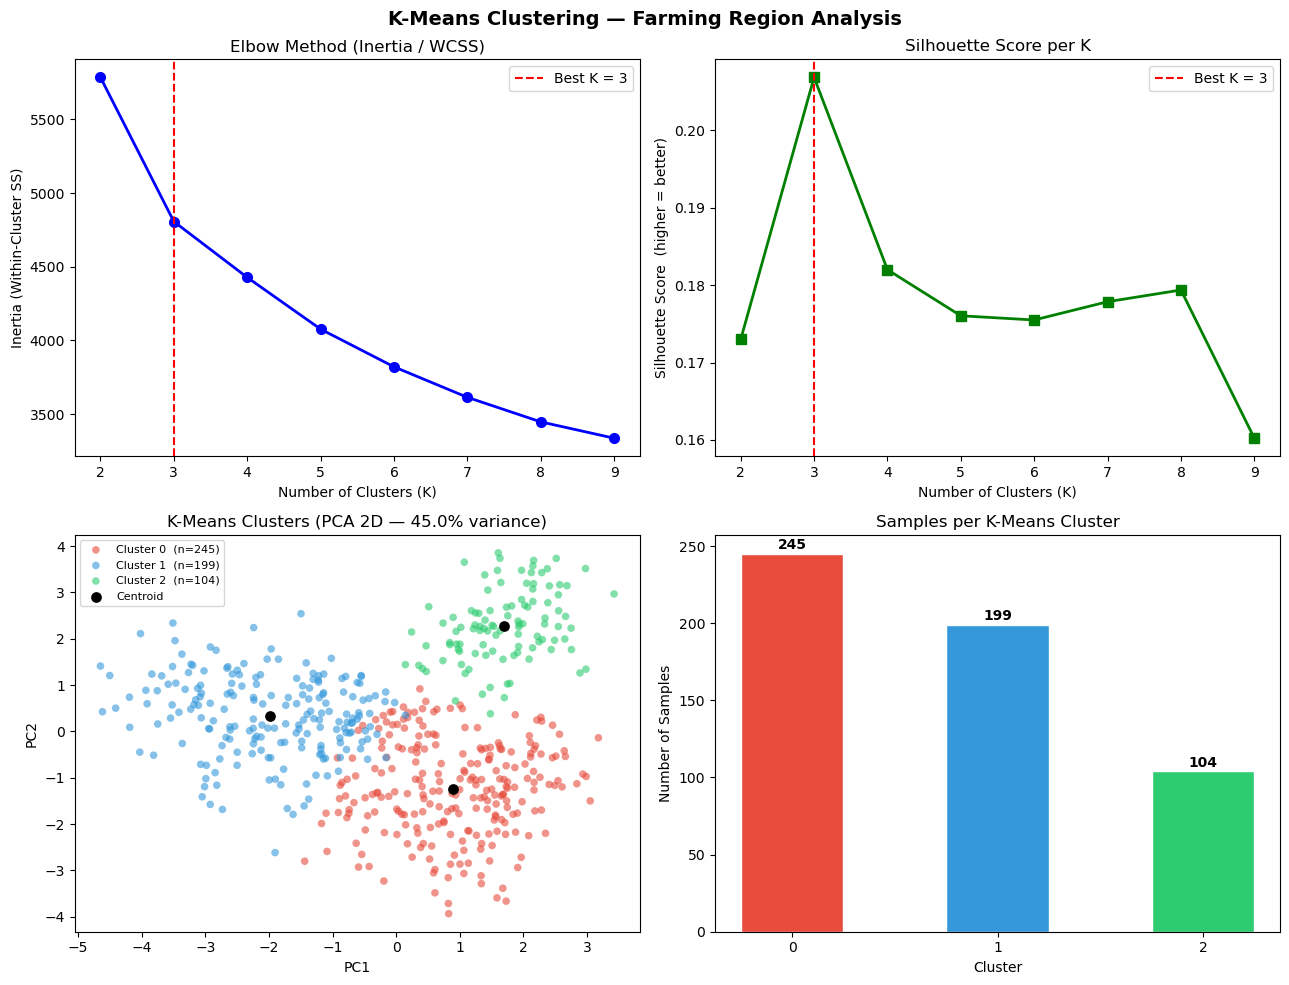

Saved: data/kmeans_results.png


In [4]:
colors_cl = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F39C12']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("K-Means Clustering — Farming Region Analysis",
             fontsize=14, fontweight='bold')

# Elbow Method
axes[0, 0].plot(K_range, inertias, 'bo-', markersize=7, linewidth=2)
axes[0, 0].axvline(BEST_K, color='red', linestyle='--',
                   label=f'Best K = {BEST_K}')
axes[0, 0].set_title("Elbow Method (Inertia / WCSS)")
axes[0, 0].set_xlabel("Number of Clusters (K)")
axes[0, 0].set_ylabel("Inertia (Within-Cluster SS)")
axes[0, 0].legend()

# Silhouette Score
axes[0, 1].plot(K_range, sil_scores, 'gs-', markersize=7, linewidth=2)
axes[0, 1].axvline(BEST_K, color='red', linestyle='--',
                   label=f'Best K = {BEST_K}')
axes[0, 1].set_title("Silhouette Score per K")
axes[0, 1].set_xlabel("Number of Clusters (K)")
axes[0, 1].set_ylabel("Silhouette Score  (higher = better)")
axes[0, 1].legend()

# PCA 2D Scatter
for cl in range(BEST_K):
    mask = km_labels == cl
    axes[1, 0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=colors_cl[cl],
                       label=f"Cluster {cl}  (n={mask.sum()})",
                       alpha=0.6, s=30, edgecolors='none')
    
centroids_2d = pca.transform(kmeans.cluster_centers_)
axes[1, 0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                   c='black', marker='.', s=180, zorder=5, label='Centroid')
axes[1, 0].set_title(f"K-Means Clusters (PCA 2D — {explained:.1f}% variance)")
axes[1, 0].set_xlabel("PC1"); axes[1, 0].set_ylabel("PC2")
axes[1, 0].legend(fontsize=8)

# Cluster Size Bar Chart
cluster_sizes = pd.Series(km_labels).value_counts().sort_index()
bars = axes[1, 1].bar(cluster_sizes.index, cluster_sizes.values,
                      color=colors_cl[:BEST_K], edgecolor='white', width=0.5)
for bar, val in zip(bars, cluster_sizes.values):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, val + 3,
                    str(val), ha='center', fontweight='bold', fontsize=10)
axes[1, 1].set_title("Samples per K-Means Cluster")
axes[1, 1].set_xlabel("Cluster"); axes[1, 1].set_ylabel("Number of Samples")
axes[1, 1].set_xticks(cluster_sizes.index)

plt.tight_layout()
plt.savefig("data/kmeans_results.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: data/kmeans_results.png")


  AGRONOMIC PROFILE PER CLUSTER (mean of original values)
         soil_ph  nitrogen  phosphorus  potassium  temperature  humidity  rainfall
Cluster                                                                           
0           6.70     79.31       44.23      41.92        25.66     59.23     94.35
1           6.35    110.67       62.30      75.36        19.13     67.48     96.40
2           6.28     92.56       45.37      45.42        29.29     80.21    196.05


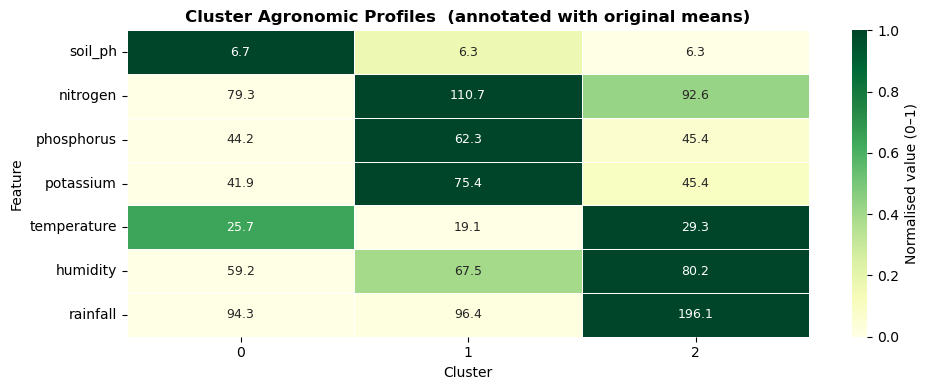

Saved: data/cluster_profiles.png


In [5]:
# K-Means: Agricultural Profile per Cluster
with open('data/scaler.pkl', 'rb') as f:
    scaler, feature_order = pickle.load(f)

X_original = scaler.inverse_transform(X_scaled)
df_orig    = pd.DataFrame(X_original, columns=CLUSTER_FEATURES)
df_orig['Cluster'] = km_labels

# Select numberic feature
agro_cols = ['soil_ph', 'nitrogen', 'phosphorus', 'potassium',
             'temperature', 'humidity', 'rainfall']

profile = df_orig.groupby('Cluster')[agro_cols].mean().round(2)
print("\n  AGRONOMIC PROFILE PER CLUSTER (mean of original values)")
print(profile.to_string())

# heatmap of cluster profiles
fig_p, ax_p = plt.subplots(figsize=(10, 4))
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
sns.heatmap(profile_norm.T, annot=profile.T, fmt='.1f',
            cmap='YlGn', linewidths=0.4, ax=ax_p,
            cbar_kws={'label': 'Normalised value (0–1)'},
            annot_kws={'size': 9})
ax_p.set_title("Cluster Agronomic Profiles  (annotated with original means)",
               fontsize=12, fontweight='bold')
ax_p.set_xlabel("Cluster"); ax_p.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("data/cluster_profiles.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: data/cluster_profiles.png")

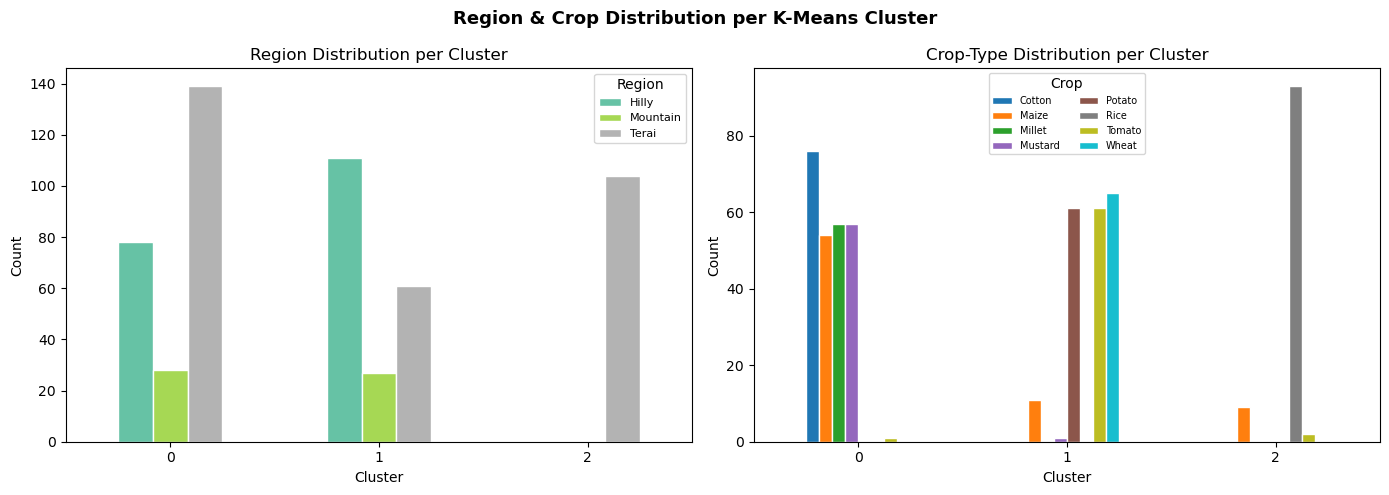

Saved: data/cluster_region_crop.png


In [6]:
# K-Means: Region & Crop-Type Distribution per Cluster
le_region = label_encoders['region']
le_crop   = label_encoders['crop_type']

df_orig['region_name'] = le_region.inverse_transform(
    df_orig['region'].round().astype(int).clip(0, len(le_region.classes_) - 1))
df_orig['crop_name']   = le_crop.inverse_transform(
    df_orig['crop_type'].round().astype(int).clip(0, len(le_crop.classes_) - 1))

fig_rc, axes_rc = plt.subplots(1, 2, figsize=(14, 5))
fig_rc.suptitle("Region & Crop Distribution per K-Means Cluster",
                fontsize=13, fontweight='bold')

# Region distribution
region_cluster = (df_orig.groupby(['Cluster', 'region_name'])
                         .size().unstack(fill_value=0))
region_cluster.plot(kind='bar', ax=axes_rc[0], colormap='Set2',
                    edgecolor='white')
axes_rc[0].set_title("Region Distribution per Cluster")
axes_rc[0].set_xlabel("Cluster"); axes_rc[0].set_ylabel("Count")
axes_rc[0].tick_params(axis='x', rotation=0)
axes_rc[0].legend(title='Region', fontsize=8)

# Crop-type distribution
crop_cluster = (df_orig.groupby(['Cluster', 'crop_name'])
                       .size().unstack(fill_value=0))
crop_cluster.plot(kind='bar', ax=axes_rc[1], colormap='tab10',
                  edgecolor='white')
axes_rc[1].set_title("Crop-Type Distribution per Cluster")
axes_rc[1].set_xlabel("Cluster"); axes_rc[1].set_ylabel("Count")
axes_rc[1].tick_params(axis='x', rotation=0)
axes_rc[1].legend(title='Crop', fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("data/cluster_region_crop.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: data/cluster_region_crop.png")

# DB scan Clustering

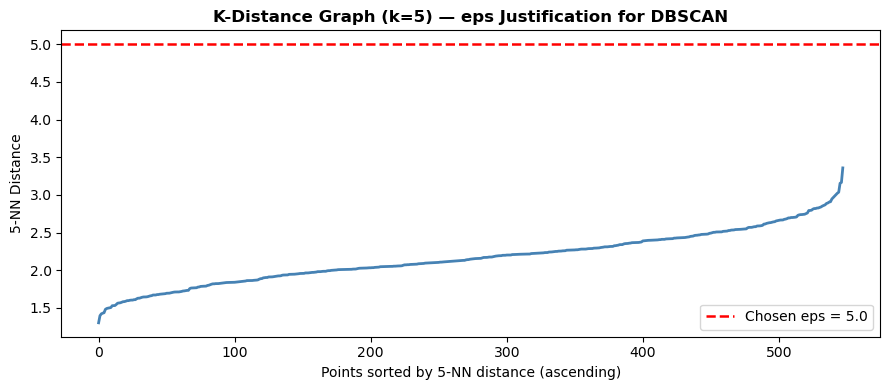

Saved: data/dbscan_eps.png
The elbow / inflection point ≈ 5.0 → we set eps = 5.0


In [7]:
# DBSCAN

nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
# Sort
k_dist_sorted = np.sort(distances[:, 4])

fig_eps, ax_eps = plt.subplots(figsize=(9, 4))
ax_eps.plot(k_dist_sorted, color='steelblue', linewidth=2)
ax_eps.axhline(5.0, color='red', linestyle='--', linewidth=1.8,
               label='Chosen eps = 5.0')
ax_eps.set_title("K-Distance Graph (k=5) — eps Justification for DBSCAN",
                 fontweight='bold')
ax_eps.set_xlabel("Points sorted by 5-NN distance (ascending)")
ax_eps.set_ylabel("5-NN Distance")
ax_eps.legend()
plt.tight_layout()
plt.savefig("data/dbscan_eps.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: data/dbscan_eps.png")
print("The elbow / inflection point ≈ 5.0 → we set eps = 5.0")

In [11]:
# DBSCAN Fit

dbscan    = DBSCAN(eps=5.0, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = list(db_labels).count(-1)

print(f"DBSCAN  |  eps=5.0  |  min_samples=5")
print(f"  Clusters found : {n_db_clusters}")
print(f"  Noise points   : {n_noise}  ({n_noise / len(db_labels) * 100:.1f}%)")

# Silhouette only makes sense when there are ≥2 clusters
if n_db_clusters > 1:
    valid  = db_labels != -1
    sil_db = silhouette_score(X_scaled[valid], db_labels[valid])
    print(f"  Silhouette (non-noise) : {sil_db:.4f}")
else:
    sil_db = None
    print(f"Silhouette : N/A (only :{n_db_clusters} cluster found.)")

DBSCAN  |  eps=5.0  |  min_samples=5
  Clusters found : 1
  Noise points   : 0  (0.0%)
Silhouette : N/A (only :1 cluster found.)


# DB Scan Visualization

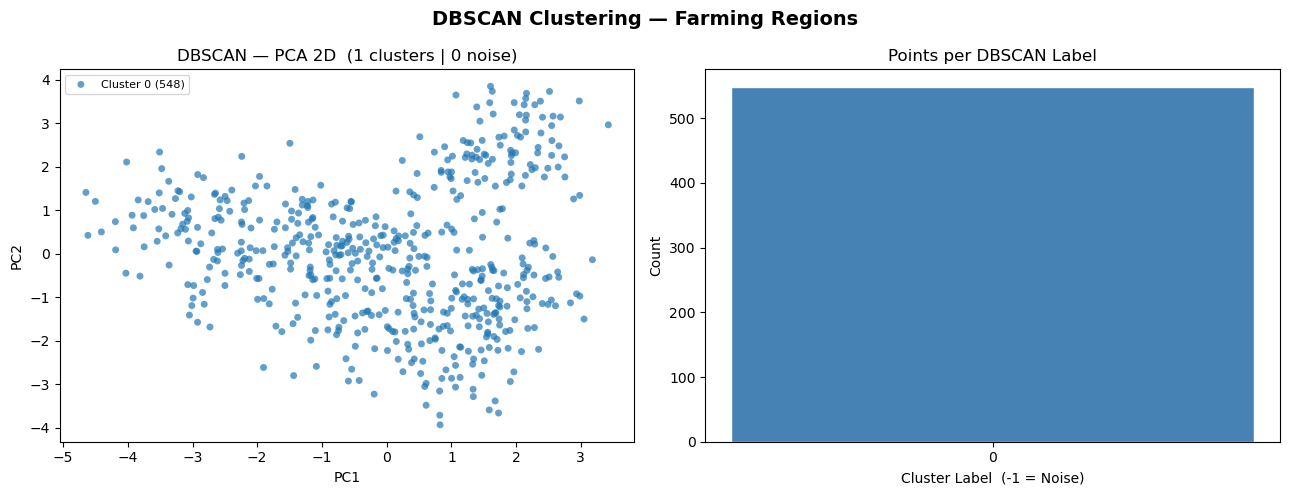

Saved: data/dbscan_results.png


In [12]:
# DBSCAN Visualisation

fig4, axes4 = plt.subplots(1, 2, figsize=(13, 5))
fig4.suptitle("DBSCAN Clustering — Farming Regions",
              fontsize=14, fontweight='bold')

unique_labels = sorted(set(db_labels))
tab_colors    = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 3)))

# PCA 2D Scatter
for i, lbl in enumerate(unique_labels):
    mask  = db_labels == lbl
    label = f"Noise ({mask.sum()})" if lbl == -1 \
            else f"Cluster {lbl} ({mask.sum()})"
    clr   = 'grey' if lbl == -1 else tab_colors[i]
    alpha = 0.25   if lbl == -1 else 0.7
    axes4[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                     c=[clr], label=label,
                     alpha=alpha, s=25, edgecolors='none')
axes4[0].set_title(f"DBSCAN — PCA 2D  ({n_db_clusters} clusters | {n_noise} noise)")
axes4[0].set_xlabel("PC1"); axes4[0].set_ylabel("PC2")
axes4[0].legend(fontsize=8)

# Count bar chart
lbl_counts = pd.Series(db_labels).value_counts().sort_index()
bar_clrs   = ['grey' if l == -1 else 'steelblue' for l in lbl_counts.index]
axes4[1].bar([str(l) if l != -1 else 'Noise' for l in lbl_counts.index],
             lbl_counts.values, color=bar_clrs, edgecolor='white')
axes4[1].set_title("Points per DBSCAN Label")
axes4[1].set_xlabel("Cluster Label  (-1 = Noise)")
axes4[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("data/dbscan_results.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: data/dbscan_results.png")

# Cluster Comparing 

In [15]:
sil_km = silhouette_score(X_scaled, km_labels)
sil_db_str = f"{sil_db:.4f}" if sil_db is not None else "N/A (1 cluster)"

print("\n  Clustering Algorithm Comparison:")
print(f"  {'Algorithm':<30} {'Silhouette':>12} {'Clusters':>10} {'Noise pts':>10}")
print("  " + "-" * 65)
print(f"  {'K-Means (k='+str(BEST_K)+')':<30} {sil_km:>12.4f} {BEST_K:>10} {'N/A':>10}")
print(f"  {'DBSCAN (eps=5.0, ms=5)':<30} {sil_db_str:>12} {n_db_clusters:>10} {n_noise:>10}")
print()
print("  Interpretation:")
print("  - K-Means is best when clusters are roughly spherical and equal-sized.")
print("  - DBSCAN is best when clusters have irregular shapes or you want outlier detection.")


  Clustering Algorithm Comparison:
  Algorithm                        Silhouette   Clusters  Noise pts
  -----------------------------------------------------------------
  K-Means (k=3)                        0.2068          3        N/A
  DBSCAN (eps=5.0, ms=5)         N/A (1 cluster)          1          0

  Interpretation:
  - K-Means is best when clusters are roughly spherical and equal-sized.
  - DBSCAN is best when clusters have irregular shapes or you want outlier detection.


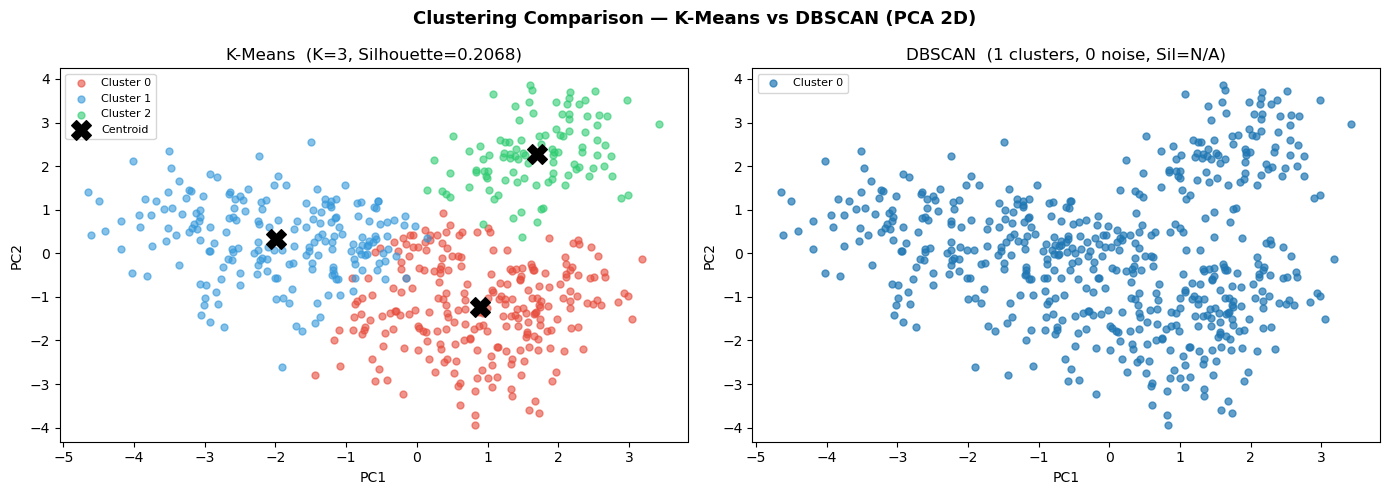

Saved: data/clustering_comparison.png


In [16]:
# ─────────────────────────────────────────────────────────────
# Side-by-side PCA Comparison Plot
# ─────────────────────────────────────────────────────────────

fig_cmp, axes_cmp = plt.subplots(1, 2, figsize=(14, 5))
fig_cmp.suptitle("Clustering Comparison — K-Means vs DBSCAN (PCA 2D)",
                 fontsize=13, fontweight='bold')

# K-Means panel
for cl in range(BEST_K):
    mask = km_labels == cl
    axes_cmp[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                        c=colors_cl[cl],
                        label=f"Cluster {cl}",
                        alpha=0.6, s=25)
axes_cmp[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                    c='black', marker='X', s=200, zorder=5, label='Centroid')
axes_cmp[0].set_title(f"K-Means  (K={BEST_K}, Silhouette={sil_km:.4f})")
axes_cmp[0].set_xlabel("PC1"); axes_cmp[0].set_ylabel("PC2")
axes_cmp[0].legend(fontsize=8)

# DBSCAN panel
for i, lbl in enumerate(sorted(set(db_labels))):
    mask  = db_labels == lbl
    label = "Noise" if lbl == -1 else f"Cluster {lbl}"
    clr   = 'grey' if lbl == -1 else tab_colors[i]
    alpha = 0.2 if lbl == -1 else 0.7
    axes_cmp[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                        c=[clr], label=label, alpha=alpha, s=25)
sil_title = f"Sil={sil_db:.4f}" if sil_db else "Sil=N/A"
axes_cmp[1].set_title(f"DBSCAN  ({n_db_clusters} clusters, {n_noise} noise, {sil_title})")
axes_cmp[1].set_xlabel("PC1"); axes_cmp[1].set_ylabel("PC2")
axes_cmp[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("data/clustering_comparison.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: data/clustering_comparison.png")

In [18]:
result_df = pd.read_csv("data/cleaned_data.csv")
result_df['KMeans_Cluster'] = km_labels
result_df['DBSCAN_Cluster'] = db_labels
result_df.to_csv("data/cluster_results.csv", index=False)
print("Saved: data/cluster_results.csv")

# Cluster summary 
df_orig['KMeans_Cluster'] = km_labels
summary_table = df_orig.groupby('KMeans_Cluster')[agro_cols].agg(['mean', 'std']).round(2)
summary_table.to_csv("data/cluster_summary.csv")
print("Saved: data/cluster_summary.csv")

print("\n Farming Region Clustering done.")

Saved: data/cluster_results.csv
Saved: data/cluster_summary.csv

 Farming Region Clustering done.
